EX 1: Anomaly detection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest


In [2]:
X = np.array([[1], [2],[2.1],[2.2], [100]])

In [3]:
model = IsolationForest(contamination=0.2)
model.fit(X)

IsolationForest(contamination=0.2)

In [4]:
y_pred = model.predict(X)


In [5]:
y_pred

array([ 1,  1,  1,  1, -1])

Ex 2: IsolationForest Implementation for one class

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

In [7]:
rng = np.random.RandomState(42)
X_normal = 0.3 * rng.randn(200, 2)

In [8]:
# Add anomaly (outliers)
X_outliers = rng.uniform(low=-4, high=4, size=(20,2))

In [9]:
#Combine dataset
X = np.vstack([X_normal, X_outliers])

In [10]:
#Apply model
model = IsolationForest(contamination=0.2, random_state=42)
model.fit(X)

IsolationForest(contamination=0.2, random_state=42)

In [11]:
y_pred = model.predict(X)

In [12]:
y_pred

array([ 1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1, -1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1, -1,  1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [15]:
# Separate normal and anomaly classes
normal_points = X[y_pred == 1]
anomaly_points = X[y_pred == -1]

In [17]:
normal_points.shape

(176, 2)

In [18]:
anomaly_points.shape

(44, 2)

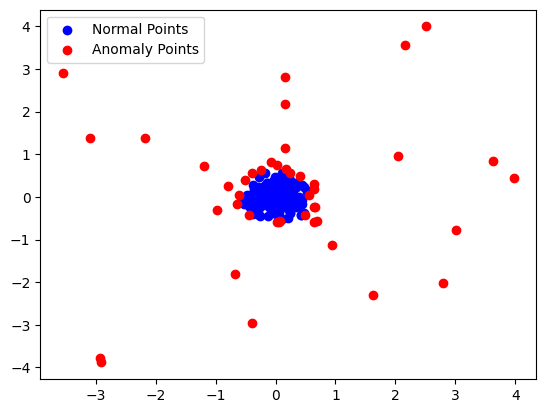

In [20]:
plt.scatter(normal_points[:,0], normal_points[:,1], c='blue', label ='Normal Points')
plt.scatter(anomaly_points[:,0], anomaly_points[:,1], c='red', label ='Anomaly Points')
plt.legend()
plt.show()

Ex 2 : Anomaly detection in Salary values

In [21]:
df = pd.read_csv('/content/Salary_Data (2).csv')
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [23]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [24]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


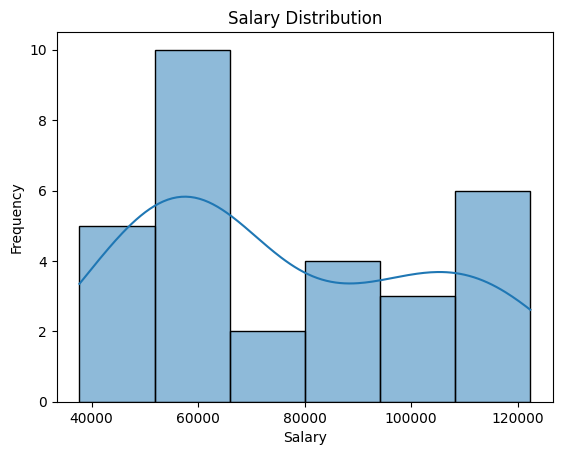

In [25]:
sns.histplot(df['Salary'], kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

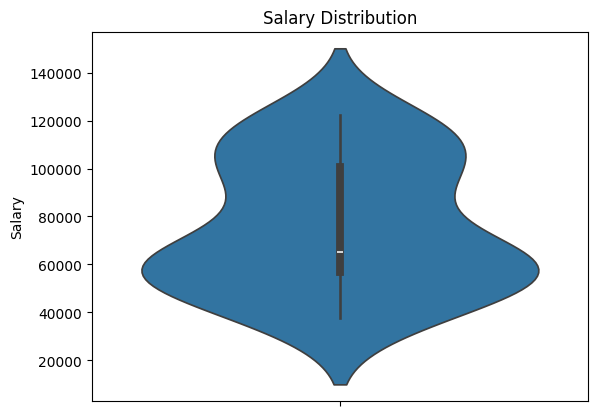

In [26]:
sns.violinplot(y=df['Salary'], data=df)
plt.title('Salary Distribution')
plt.show()

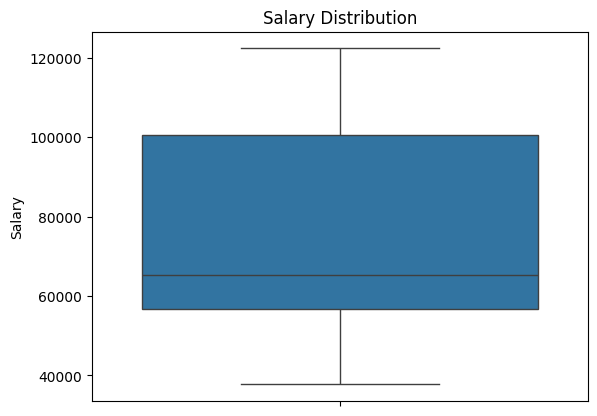

In [27]:
sns.boxplot(y=df['Salary'], data=df)
plt.title('Salary Distribution')
plt.show()

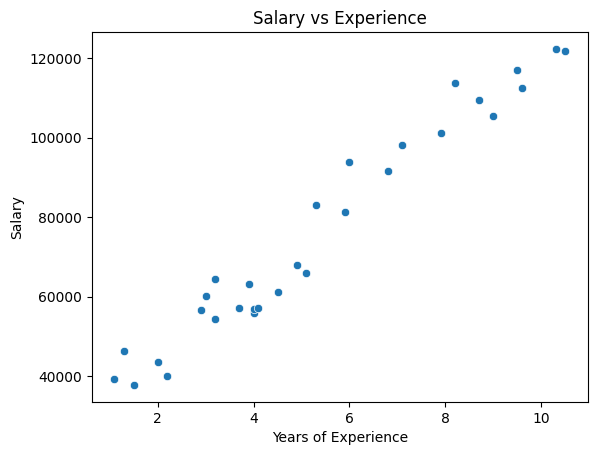

In [28]:
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title('Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [29]:
df['Salary_per_year'] = df['Salary']/(df['YearsExperience'] + 1)

In [30]:
df['Log_Salary'] = np.log(df['Salary'])

In [31]:
X = df[['YearsExperience','Salary','Salary_per_year','Log_Salary']]

In [32]:
X

,YearsExperience,Salary,Salary_per_year,Log_Salary
0,1.1,39343.0,18734.761905,10.580073
1,1.3,46205.0,20089.130435,10.740843
2,1.5,37731.0,15092.400000,10.538237
3,2.0,43525.0,14508.333333,10.681091
4,2.2,39891.0,12465.937500,10.593906
5,2.9,56642.0,14523.589744,10.944506
6,3.0,60150.0,15037.500000,11.004597
7,3.2,54445.0,12963.095238,10.904946
8,3.2,64445.0,15344.047619,11.073567
9,3.7,57189.0,12167.872340,10.954117


In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

In [35]:
#Apply model
model = IsolationForest(contamination=0.2, random_state=42)
model.fit(X_sc)

IsolationForest(contamination=0.2, random_state=42)

In [37]:
y_pred = model.predict(X_sc)
y_pred

array([-1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1])

In [38]:
# Separate normal and anomaly classes
normal_points = X[y_pred == 1]
anomaly_points = X[y_pred == -1]

Ex 3: Point Anomaly

In [40]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.7/364.7 kB 9.9 MB/s eta 0:00:00


In [41]:
import numpy as np
from pyod.models.knn import KNN

In [42]:
np.random.seed(42)

X_normal = np.random.randn(300,2)

In [43]:
#Add anomaly
point_anomaly = np.array([[8,8]])

In [44]:
X = np.vstack([X_normal, point_anomaly])

Text(0, 0.5, 'Feature 2')

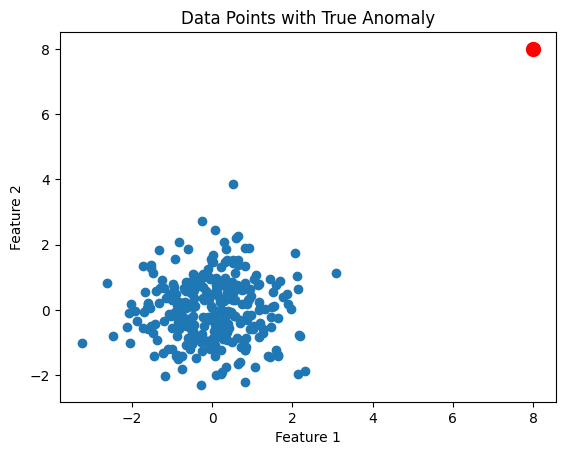

In [46]:
plt.scatter(X[:,0], X[:, 1], label='Data Points')
plt.scatter(point_anomaly[:, 0], point_anomaly[:,1], color='red', label='True Anomaly', s=100)
plt.title('Data Points with True Anomaly')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

In [48]:
#Apply Model
clf = KNN(contamination=0.01) #1% of anomaly
clf.fit(X)

KNN(algorithm='auto', contamination=0.01, leaf_size=30, method='largest',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=5, p=2,
  radius=1.0)

In [49]:
y_pred = clf.predict(X)  # 0=Normal, 1=Anomaly

In [51]:
score = clf.decision_scores_
score

array([0.17273881, 0.28668597, 0.24977057, 0.41026775, 0.21865857,
       0.22162611, 0.51873964, 0.34041433, 0.19172484, 0.29330046,
       0.32118334, 0.34701861, 0.18198898, 0.2092527 , 0.18071934,
       0.70082285, 0.11297679, 0.36484302, 0.55327857, 0.33428825,
       0.25032491, 0.20270619, 0.30579087, 0.24650251, 0.37416689,
       0.1660061 , 0.21865857, 0.29028681, 0.13839969, 0.23029136,
       0.26427237, 0.37467772, 0.34220749, 0.23811236, 0.09743708,
       0.28668597, 0.3580453 , 1.10053385, 0.17931958, 0.56334216,
       0.22552675, 0.30246491, 0.18117089, 0.26309813, 0.1770336 ,
       0.23428751, 0.12360355, 0.42223789, 0.22866171, 0.13786896,
       0.34041433, 0.19092687, 0.18451111, 0.39676369, 0.16043105,
       0.32852208, 0.65108328, 0.25166507, 0.15177308, 0.32332421,
       0.29801581, 0.49594347, 0.44059197, 0.26918755, 0.15768805,
       0.25682023, 0.16491054, 0.6424605 , 0.09929341, 0.37515768,
       0.33088118, 0.27956471, 0.18907424, 0.36667125, 0.25032

In [53]:
print("Total points=",len(X))
print("Normal points=",sum(y_pred==0))
print("Anomaly points=",sum(y_pred==1))

Total points= 301
Normal points= 298
Anomaly points= 3


In [54]:
print("Detected anomaly=" , np.sum(y_pred))

Detected anomaly= 3


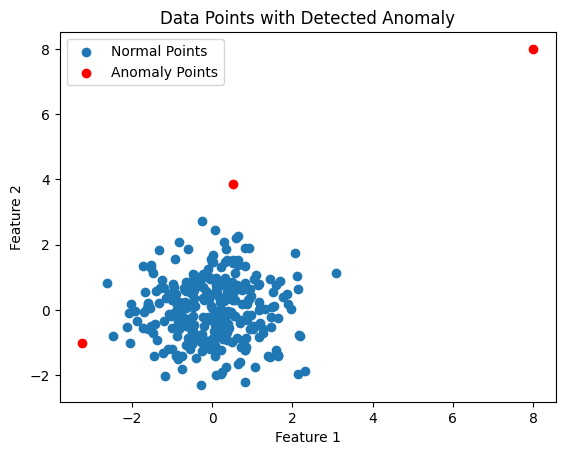

In [56]:
plt.scatter(X[y_pred == 0][:, 0], X[y_pred == 0][:, 1], label='Normal Points')
plt.scatter(X[y_pred == 1][:, 0], X[y_pred == 1][:, 1], color='red', label='Anomaly Points')
plt.title('Data Points with Detected Anomaly')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

EX: Collective Anomaly

In [57]:
import numpy as np
from pyod.models.knn import KNN

In [58]:
np.random.seed(42)
X_normal = np.random.randn(300,2)

In [59]:
#Add anomaly
coll_anomaly = np.random.uniform(low=-6, high=6, size=(20,2))

In [60]:
X = np.vstack([X_normal, coll_anomaly])

In [62]:
y_true = np.zeros(len(X))
y_true[-20:] = 1 # last 20 are anomalies

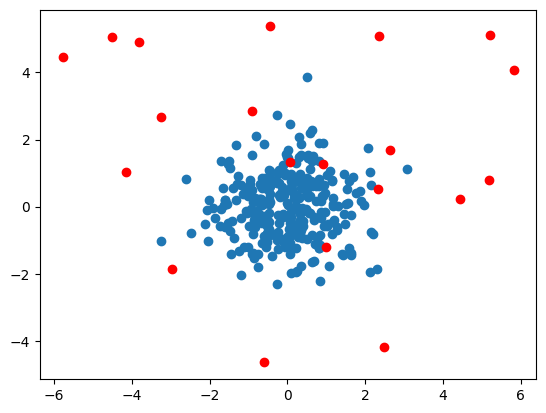

In [63]:
plt.scatter(X_normal[:,0], X_normal[:,1], label='Normal')
plt.scatter(coll_anomaly[:,0], coll_anomaly[:,1], color='red', label='Collective Anomaly')
plt.show()

In [64]:
#Apply Model
clf = KNN(contamination=0.1) # 10% anomalies
clf.fit(X)

KNN(algorithm='auto', contamination=0.1, leaf_size=30, method='largest',
  metric='minkowski', metric_params=None, n_jobs=1, n_neighbors=5, p=2,
  radius=1.0)

In [65]:
y_pred = clf.predict(X) #0=Normal, 1=Anomaly
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [66]:
scores = clf.decision_scores_
scores

array([0.17273881, 0.28668597, 0.24977057, 0.41026775, 0.21865857,
       0.22162611, 0.51873964, 0.34041433, 0.19172484, 0.29330046,
       0.32118334, 0.34701861, 0.18198898, 0.2092527 , 0.18071934,
       0.70082285, 0.11297679, 0.31304637, 0.55327857, 0.33428825,
       0.25032491, 0.20270619, 0.30579087, 0.24650251, 0.37416689,
       0.1660061 , 0.21865857, 0.29028681, 0.13839969, 0.23029136,
       0.26427237, 0.37467772, 0.32723815, 0.23811236, 0.09743708,
       0.28668597, 0.33617254, 1.10053385, 0.17931958, 0.56334216,
       0.22552675, 0.30246491, 0.18117089, 0.26309813, 0.1770336 ,
       0.23428751, 0.12360355, 0.42223789, 0.22866171, 0.13786896,
       0.34041433, 0.19092687, 0.18451111, 0.39676369, 0.16043105,
       0.32852208, 0.65108328, 0.25166507, 0.15177308, 0.32332421,
       0.29801581, 0.45458933, 0.44059197, 0.26918755, 0.15768805,
       0.25682023, 0.16491054, 0.6424605 , 0.09929341, 0.32226225,
       0.29204249, 0.27956471, 0.18907424, 0.36667125, 0.25032

In [67]:
print("Total points= ", len(X))
print("Normal points= ", sum(y_pred))
print("Detected Anomaly= ", X[y_pred == 1])

Total points=  320
Normal points=  30
Detected Anomaly=  [[-2.6197451   0.8219025 ]
 [-0.26465683  2.72016917]
 [ 0.51504769  3.85273149]
 [ 2.31465857 -1.86726519]
 [-3.24126734 -1.02438764]
 [ 2.13303337 -1.9520878 ]
 [-0.81822068  2.09238728]
 [ 2.15318246 -0.76734756]
 [ 2.18980293 -0.80829829]
 [ 2.06074792  1.75534084]
 [-1.18325851 -2.03923218]
 [-0.2750517  -2.30192116]
 [ 3.07888081  1.11957491]
 [-2.4716445  -0.79689526]
 [-3.24898326  2.66703082]
 [ 2.64043844  1.69377159]
 [-2.97841129 -1.85164808]
 [-3.8208274   4.90140674]
 [-0.45593036  5.36740008]
 [-4.15978316  1.03475798]
 [-5.78267779  4.46548691]
 [ 5.18541939  0.7815982 ]
 [ 2.35980989  5.06999257]
 [ 2.48686361 -4.16953149]
 [-0.91043194  2.83733083]
 [ 5.21240418  5.10682215]
 [-0.58992754 -4.64114345]
 [ 5.81809439  4.06677704]
 [-4.50404783  5.05010259]
 [ 4.43875634  0.22605669]]


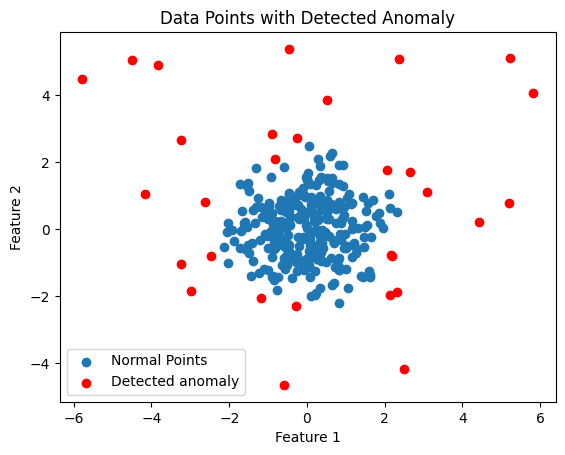

In [69]:
plt.scatter(X[y_pred == 0][:, 0], X[y_pred == 0][:,1], label='Normal Points')
plt.scatter(X[y_pred == 1][:, 0], X[y_pred == 1][:, 1], color='red', label='Detected anomaly')
plt.title('Data Points with Detected Anomaly')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [70]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[286  14]
 [  4  16]]


In [71]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.99      0.95      0.97       300
         1.0       0.53      0.80      0.64        20

    accuracy                           0.94       320
   macro avg       0.76      0.88      0.80       320
weighted avg       0.96      0.94      0.95       320



Ex : 5 Contextual Anomaly

In [99]:
import numpy as np
from pyod.models.knn import KNN

In [100]:
np.random.seed(42)

time = np.arange(0, 100, 0.01)

In [101]:
#Normal pattern
contextual_normal = np.sin(time)

In [102]:
#inject anomaly
contextual_anomaly = np.sin(time)
contextual_anomaly[500:600] = 3 #Abnormal spike

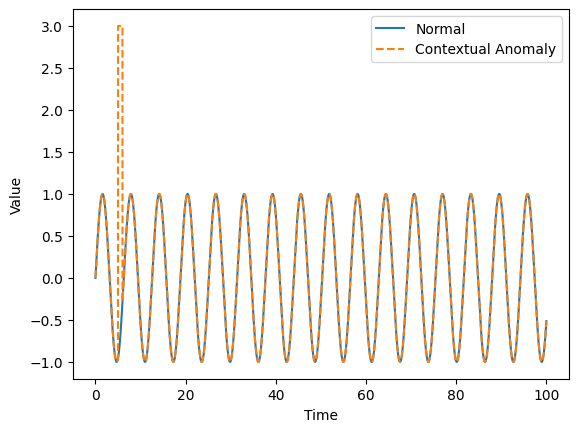

In [103]:
plt.plot(time, contextual_normal, label='Normal')
plt.plot(time, contextual_anomaly, label='Contextual Anomaly', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

In [104]:
# Anomaly detection
mean = np.mean(contextual_anomaly)
std = np.std(contextual_anomaly)

In [105]:
#Normalization
Z_score = (contextual_anomaly - mean)/std

In [106]:
# Threshold
threshold = 3
anomallies = np.abs(Z_score) > threshold

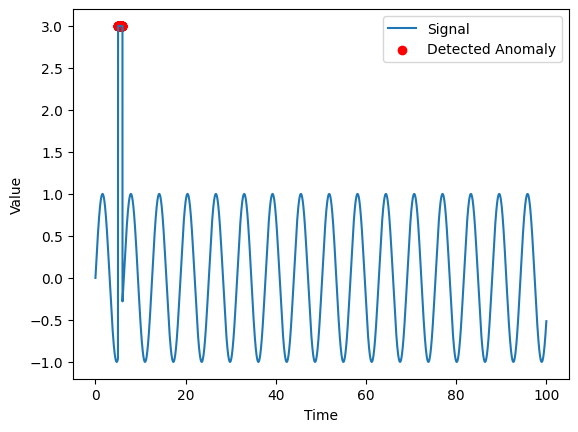

In [107]:
#Visualize the anomaly

plt.plot(time, contextual_anomaly, label='Signal')
plt.scatter(time[anomallies], contextual_anomaly[anomallies], color='red', label='Detected Anomaly')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

In [108]:
# Final Result
print("Total anomalies =", np.sum(anomallies))
print("Anomaly indices = ", np.where(anomallies)[0])

Total anomalies = 100
Anomaly indices =  [500 501 502 503 504 505 506 507 508 509 510 511 512 513 514 515 516 517
 518 519 520 521 522 523 524 525 526 527 528 529 530 531 532 533 534 535
 536 537 538 539 540 541 542 543 544 545 546 547 548 549 550 551 552 553
 554 555 556 557 558 559 560 561 562 563 564 565 566 567 568 569 570 571
 572 573 574 575 576 577 578 579 580 581 582 583 584 585 586 587 588 589
 590 591 592 593 594 595 596 597 598 599]
